In [400]:
import numpy as np

AND_J_MAT = np.array([[0, 1, -2, -1], [1, 0, -2, -1], [-2, -2, 0, 2], [-1, -1, 2, 0]])
OR_J_MAT = np.array([[0, 1, -2, 1], [1, 0, -2, 1], [-2, -2, 0, -2], [1, 1, -2, 0]])

XOR_J_MAT = np.array(
    [
        [0, 1, -1, -2, -1],
        [1, 0, -1, -2, -1],
        [-1, -1, 0, 2, 1],
        [-2, -2, 2, 0, 2],
        [-1, -1, 1, 2, 0],
    ]
)

OR3_J_MAT = np.array(
    [
        [0, 1, 1, -2, -3, -1],
        [1, 0, 1, -2, -3, -1],
        [1, 1, 0, -2, -3, -1],
        [-2, -2, -2, 0, 4, 0],
        [-3, -3, -3, 4, 0, 3],
        [-1, -1, -1, 0, 3, 0],
    ]
)

## Symbolic Integration/Differentiation of Energy Function

In [29]:
import sympy as sp

In [153]:
n_harmonic = 2
sep = 2 * sp.pi / n_harmonic


def energy_fn(n_osc) -> sp.Expr:
    phases = sp.symbols([f"x_{i}" for i in range(n_osc)])
    phases = list(phases) + [sp.pi]  # fixed reference phase
    j_values = sp.symbols(
        [f"J_{i}_{j}" for i in range(n_osc + 1) for j in range(i + 1, n_osc + 1)]
    )
    Ac, Al = sp.symbols(["A_c", "A_l"])
    energy = 0
    for i in range(n_osc):
        for j in range(i + 1, n_osc + 1):
            cpl = sp.Symbol(f"J_{min(i,j)}_{max(i,j)}")
            energy += (
                Ac
                * cpl
                * (sp.cos(phases[i] - phases[j]) + sp.cos(phases[j] - phases[i]))
            )
        energy -= Al * sp.cos(n_harmonic * phases[i])
    return energy


print("Energy function:")
e = energy_fn(3)
display(e)

dedp = sp.Matrix([sp.diff(e, sp.symbols(f"x_{i}")) for i in range(3)])
print("dE/dphi:")
display(dedp)

# Hessian
print("Hessian:")
H = sp.Matrix(
    [[sp.diff(dedp[i], sp.symbols(f"x_{j}")) for j in range(3)] for i in range(3)]
)
display(H)

Energy function:


2*A_c*J_0_1*cos(x_0 - x_1) + 2*A_c*J_0_2*cos(x_0 - x_2) - 2*A_c*J_0_3*cos(x_0) + 2*A_c*J_1_2*cos(x_1 - x_2) - 2*A_c*J_1_3*cos(x_1) - 2*A_c*J_2_3*cos(x_2) - A_l*cos(2*x_0) - A_l*cos(2*x_1) - A_l*cos(2*x_2)

dE/dphi:


Matrix([
[-2*A_c*J_0_1*sin(x_0 - x_1) - 2*A_c*J_0_2*sin(x_0 - x_2) + 2*A_c*J_0_3*sin(x_0) + 2*A_l*sin(2*x_0)],
[ 2*A_c*J_0_1*sin(x_0 - x_1) - 2*A_c*J_1_2*sin(x_1 - x_2) + 2*A_c*J_1_3*sin(x_1) + 2*A_l*sin(2*x_1)],
[ 2*A_c*J_0_2*sin(x_0 - x_2) + 2*A_c*J_1_2*sin(x_1 - x_2) + 2*A_c*J_2_3*sin(x_2) + 2*A_l*sin(2*x_2)]])

Hessian:


Matrix([
[-2*A_c*J_0_1*cos(x_0 - x_1) - 2*A_c*J_0_2*cos(x_0 - x_2) + 2*A_c*J_0_3*cos(x_0) + 4*A_l*cos(2*x_0),                                                                         2*A_c*J_0_1*cos(x_0 - x_1),                                                                         2*A_c*J_0_2*cos(x_0 - x_2)],
[                                                                        2*A_c*J_0_1*cos(x_0 - x_1), -2*A_c*J_0_1*cos(x_0 - x_1) - 2*A_c*J_1_2*cos(x_1 - x_2) + 2*A_c*J_1_3*cos(x_1) + 4*A_l*cos(2*x_1),                                                                         2*A_c*J_1_2*cos(x_1 - x_2)],
[                                                                        2*A_c*J_0_2*cos(x_0 - x_2),                                                                         2*A_c*J_1_2*cos(x_1 - x_2), -2*A_c*J_0_2*cos(x_0 - x_2) - 2*A_c*J_1_2*cos(x_1 - x_2) + 2*A_c*J_2_3*cos(x_2) + 4*A_l*cos(2*x_2)]])

In [154]:
def integrate_energy_recursive(
    int_energy_expr: sp.Expr,
    phase_vals: list[sp.Expr],
    j_mat: np.ndarray = AND_J_MAT,
    Ac: int = 1,
    Al: int = 1,
):
    n_osc = j_mat.shape[0] - 1
    n_integrated_var = len(phase_vals)
    if n_integrated_var == n_osc:

        subs = {
            sp.symbols(f"J_{i}_{j}"): j_mat[i, j]
            for i in range(n_osc + 1)
            for j in range(i + 1, n_osc + 1)
        } | {sp.symbols("A_c"): Ac, sp.symbols("A_l"): Al}

        var_val = [v + sep / 2 for v in phase_vals]
        energy = energy_fn(n_osc).subs(
            {sp.symbols(f"x_{i}"): var_val[i] for i in range(n_osc)}
        )
        var_range_str = ", ".join(
            [f"x{i}=[{v}, {v+sep}]" for i, v in enumerate(phase_vals)]
        )
        energy_val = energy.subs(subs)
        int_energy_val = int_energy_expr.subs(subs)

        print(f"Energy in state {[v // sp.pi for v in var_val]}:")
        display(sp.simplify(energy))
        print(f"Evaluated energy: {energy_val:.0f}")
        print(f"Integrated energy in {var_range_str}:")
        display(sp.simplify(int_energy_expr))
        print(f"Evaluated integrated energy: {int_energy_val:.2f}\n")
        return
    if n_integrated_var == 0:
        assert (
            n_osc == j_mat.shape[0] - 1
        ), "J matrix should have size (n_osc+1)x(n_osc+1)"
        print(f"Ac={Ac}, Al={Al}, J=\n{j_mat}\n")
        int_energy_expr = energy_fn(n_osc)

    int_var = sp.symbols(f"x_{n_integrated_var}")
    indef_integral = sp.integrate(int_energy_expr, int_var)
    for phase_val in [-sep / 2 + i * sep for i in range(n_harmonic)]:
        def_integral = indef_integral.subs(
            int_var, phase_val + sp.pi
        ) - indef_integral.subs(int_var, phase_val)
        integrate_energy_recursive(
            def_integral, phase_vals + [phase_val], j_mat=j_mat, Ac=Ac, Al=Al
        )


integrate_energy_recursive(None, [], j_mat=AND_J_MAT, Ac=1, Al=1)

Ac=1, Al=1, J=
[[ 0  1 -2 -1]
 [ 1  0 -2 -1]
 [-2 -2  0  2]
 [-1 -1  2  0]]

Energy in state [0, 0, 0]:


2*A_c*J_0_1 + 2*A_c*J_0_2 - 2*A_c*J_0_3 + 2*A_c*J_1_2 - 2*A_c*J_1_3 - 2*A_c*J_2_3 - 3*A_l

Evaluated energy: -9
Integrated energy in x0=[-pi/2, pi/2], x1=[-pi/2, pi/2], x2=[-pi/2, pi/2]:


4*pi*A_c*(2*J_0_1 + 2*J_0_2 - pi*J_0_3 + 2*J_1_2 - pi*J_1_3 - pi*J_2_3)

Evaluated integrated energy: -75.40

Energy in state [0, 0, 1]:


...

Evaluated integrated energy: -32.25

Energy in state [1, 1, 1]:


2*A_c*J_0_1 + 2*A_c*J_0_2 + 2*A_c*J_0_3 + 2*A_c*J_1_2 + 2*A_c*J_1_3 + 2*A_c*J_2_3 - 3*A_l

Evaluated energy: -9
Integrated energy in x0=[pi/2, 3*pi/2], x1=[pi/2, 3*pi/2], x2=[pi/2, 3*pi/2]:


4*pi*A_c*(2*J_0_1 + 2*J_0_2 + pi*J_0_3 + 2*J_1_2 + pi*J_1_3 + pi*J_2_3)

Evaluated integrated energy: -75.40



## Numerical Integration/Differentiation of the Energy Function

In [ ]:
import numpy as np
from scipy.integrate import nquad
from itertools import product
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

In [108]:
def get_energy_fn(j_mat: jax.Array, Kc: float, Kl: float, n_harmonic: int):

    @jax.jit
    def energy(phase: jax.Array):
        phase_stack = jnp.hstack([phase, jnp.array([jnp.pi])])

        phase_diffs = phase_stack[:, None] - phase_stack[None, :]
        cpl_energy = j_mat * jnp.cos(phase_diffs)
        cpl_energy = jnp.sum(cpl_energy)
        lock_energy = jnp.sum(jnp.cos(n_harmonic * phase))
        return Kc * cpl_energy - Kl * lock_energy

    return energy

In [526]:

def num_int_exp_energy(j_mat: jax.Array, beta: float, Kc: float=1.0, Kl: float=1.0, n_harmonic: int=2, range_ratio: float=1.0):
    energy = get_energy_fn(j_mat, Kc, Kl, n_harmonic)

    def exp_energy_fn(*args):
        phases = jnp.array(args)
        return jnp.exp(-beta * energy(phases))


    # Enumerate all states
    n_osc = j_mat.shape[0] - 1
    n_states = n_harmonic ** n_osc
    states = [tuple(i) for i in product(range(n_harmonic), repeat=n_osc)]

    err_w_ref = []
    pmf_w_ref = []

    for state in states:
        phase_vals = [s * (2 * np.pi / n_harmonic) for s in state]
        ranges = [
            (phase_val - np.pi / n_harmonic * range_ratio, phase_val + np.pi / n_harmonic * range_ratio)
            for phase_val in phase_vals
        ]
        integral_w_ref, int_err_w_ref = nquad(exp_energy_fn, ranges)
        pmf_w_ref.append(integral_w_ref)
        err_w_ref.append(int_err_w_ref)
        print(f"State {state}:")
        ranges_print = [(f"{l:.2f}", f"{u:.2f}") for l, u in ranges]
        print(f"Integrate from ranges {ranges_print}:")
        print(f"\t{integral_w_ref} ± {int_err_w_ref}")

    pmf_w_ref = np.array(pmf_w_ref) / np.sum(pmf_w_ref)

    # Plot Bar chart of the PDFs
    %matplotlib inline

    plt.bar(
        np.arange(n_states),
        pmf_w_ref,
        width=0.4,
    )
    plt.xticks(np.arange(n_states), states, rotation=90)
    plt.xlabel("States")
    plt.ylabel("PMF")
    plt.legend()
    plt.tight_layout()
    plt.show()

State (0, 0, 0):
Integrate from ranges [('-1.57', '1.57'), ('-1.57', '1.57'), ('-1.57', '1.57')]:
	42152271.13734444 ± 0.0976706980727613
State (0, 0, 1):
Integrate from ranges [('-1.57', '1.57'), ('-1.57', '1.57'), ('1.57', '4.71')]:
	5.412086638305489 ± 2.3395929310367317e-07
State (0, 1, 0):
Integrate from ranges [('-1.57', '1.57'), ('1.57', '4.71'), ('-1.57', '1.57')]:
	42600031.61327507 ± 0.585370572909742
State (0, 1, 1):
Integrate from ranges [('-1.57', '1.57'), ('1.57', '4.71'), ('1.57', '4.71')]:
	16765.661023248445 ± 0.0001352683293641692
State (1, 0, 0):
Integrate from ranges [('1.57', '4.71'), ('-1.57', '1.57'), ('-1.57', '1.57')]:
	42600031.61326604 ± 0.5237741304658852
State (1, 0, 1):
Integrate from ranges [('1.57', '4.71'), ('-1.57', '1.57'), ('1.57', '4.71')]:
	16765.66102324784 ± 0.00029931559840624435
State (1, 1, 0):
Integrate from ranges [('1.57', '4.71'), ('1.57', '4.71'), ('-1.57', '1.57')]:
	65186.12407548854 ± 0.0006314788883194922
State (1, 1, 1):
Integrate fr

/var/folders/zv/1cq_05k97dl9b9_kf_drhmdr0000gp/T/ipykernel_26315/3632218653.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


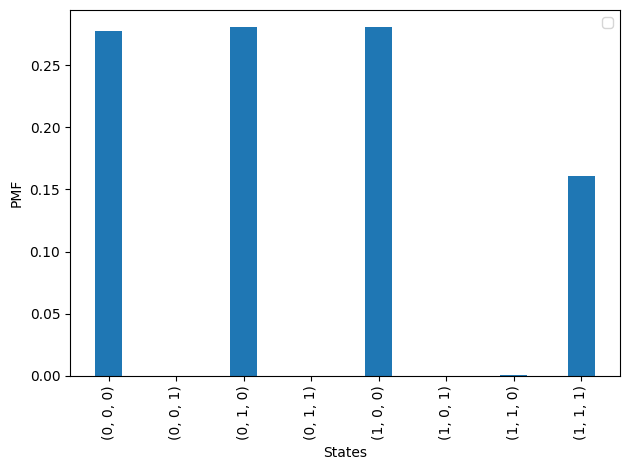

In [371]:
num_int_exp_energy(j_mat=AND_J_MAT, beta=2.0)

### Verify the energy function is the lyapunov function of the kuramoto model

In [638]:
# Test kuramoto dynamics and numerical integration of the energy function


@jax.jit
def kuramoto(phase, J: jax.Array, Kc: float, Kl: float, n_harmonic: int):
    y_w_fixed = jnp.concatenate([phase, jnp.array([jnp.pi])])  # Fixed oscillator at pi
    y_diff = y_w_fixed[:, None] - y_w_fixed[None, :]
    coupling = jnp.sum(J * jnp.sin(y_diff), axis=1)
    locking = jnp.sin(n_harmonic * y_w_fixed)
    dydt = (Kc * coupling - Kl * locking)[:-1]  # Exclude the fixed oscillator
    # dydt = coupling[:-1]
    return dydt


def verify_kuramoto_lyapunov(n_state: int):

    n_harmonic = 2  # Test the case for 2 states for now
    n_test = 10

    # test with random phases and J matrices
    for _ in range(n_test):
        # J is symmetric with zero diagonal
        j_mat = np.random.rand(n_state + 1, n_state + 1)
        j_mat = (j_mat + j_mat.T) / 2
        Kc, Kl = np.random.rand(2)
        np.fill_diagonal(j_mat, 0)
        j_mat = jnp.array(j_mat)
        phase_test = jnp.array(np.random.uniform(0, 2 * np.pi, size=n_state))

        energy = get_energy_fn(j_mat=j_mat, Kc=Kc, Kl=Kl, n_harmonic=n_harmonic)

        de_dp = jax.grad(energy, argnums=0)

        dE_dphase = de_dp(phase_test)
        dphase_dt = kuramoto(phase_test, J=j_mat, Kc=Kc, Kl=Kl, n_harmonic=n_harmonic)
        assert jnp.allclose(
            dE_dphase, 2 * -dphase_dt
        ), f"Test failed for phases {phase_test} with dE/dphase {dE_dphase} and dphase/dt {dphase_dt}"

    print(f"All {n_test} random tests passed for dE/dphase = -2dphase/dt.")


verify_kuramoto_lyapunov(n_state=4)


energy = get_energy_fn(jnp.array(OR_J_MAT), 1.0, 2.0, n_harmonic)
hessian_e = jax.jit(jax.hessian(energy, argnums=0))

states = list(product(range(n_harmonic), repeat=3))

for state in states:
    phase_vals = jnp.array([s * (2 * jnp.pi / n_harmonic) for s in state])
    hess = hessian_e(phase_vals)
    eigvals = jnp.linalg.eigvalsh(hess)
    print(f"State {state}")
    print(f"\tEnergy: {energy(phase_vals)}")
    print(f"\tCondition number of Hessian: {jnp.linalg.cond(hess)}")
    print(f"\tDeterminant of Hessian: {jnp.linalg.det(hess)}")
    print(
        f"\tLaplace approximation of probability weight: {jnp.exp(-energy(phase_vals)) * jnp.sqrt(1 / jnp.abs(jnp.linalg.det(hess)))}\n"
    )

All 10 random tests passed for dE/dphase = -2dphase/dt.
State (0, 0, 0)
	Energy: -12.0
	Condition number of Hessian: 2.5835193294852123
	Determinant of Hessian: 1360.0
	Laplace approximation of probability weight: 4413.308926838052

State (0, 0, 1)
	Energy: -4.0
	Condition number of Hessian: 14.430703308172534
	Determinant of Hessian: -16.0
	Laplace approximation of probability weight: 13.649537508286059

State (0, 1, 0)
	Energy: -4.0
	Condition number of Hessian: 124.87736264997916
	Determinant of Hessian: -16.0
	Laplace approximation of probability weight: 13.649537508286059

State (0, 1, 1)
	Energy: -12.0
	Condition number of Hessian: 3.253568211237908
	Determinant of Hessian: 848.0
	Laplace approximation of probability weight: 5589.022483666408

State (1, 0, 0)
	Energy: -4.0
	Condition number of Hessian: 124.87736264997899
	Determinant of Hessian: -16.0
	Laplace approximation of probability weight: 13.649537508286059

State (1, 0, 1)
	Energy: -12.0
	Condition number of Hessian: 3.2

In [485]:
# Minimize the energy function with noisy gradient descent and plot the distribution of final states
from tqdm.notebook import tqdm
from typing import Callable


def optimiz_energy_fn(
    j_mat,
    Kc,
    Kl,
    n_harmonic,
    lr: float = 0.01,
    noise_std: float = 0.1,
    noise_std_ratio: float = 100,
    n_trials: int = 2**12,
    n_steps: int = 50,
):
    energy = get_energy_fn(j_mat, Kc, Kl, n_harmonic)
    de_dp = jax.grad(energy, argnums=0)

    @jax.jit
    def noisy_gradient_descent_step(
        phase: jax.Array, noise_std: float, noise_seed: int
    ):
        grad = de_dp(phase)
        noise = (
            jax.random.normal(jax.random.PRNGKey(noise_seed), shape=phase.shape)
            * noise_std
        )
        phase = phase - lr * grad + noise
        return phase

    n_osc = j_mat.shape[0] - 1
    phases = jnp.array(
        np.random.uniform(-np.pi / 2, 3 * np.pi / 2, size=(n_trials, n_osc))
    )
    noise_seeds = jnp.array(np.random.randint(0, 2**31 - 1, size=(n_trials)))

    for i in tqdm(range(n_steps)):
        anneal_noise_std = (
            noise_std_ratio
            * noise_std
            * jnp.exp(-jnp.log(noise_std_ratio) * i / n_steps)
        )
        # C = noise_std
        # t = 1 / lr * (i + 1)  # Gradient flow time
        # anneal_noise_std = jnp.sqrt(C / jnp.log(t))
        phases = jax.vmap(noisy_gradient_descent_step, in_axes=(0, None, 0))(
            phases, anneal_noise_std, noise_seeds
        )

    return phases, energy


# Compute histogram of final states
def phase_to_state(phase: jax.Array, n_harmonic: int):
    state = tuple(
        ((phase + np.pi / n_harmonic) // (2 * np.pi / n_harmonic)) % n_harmonic
    )
    return state

In [486]:
%matplotlib inline

def optimize_and_plot(
    j_mat,
    Kc,
    Kl,
    n_harmonic,
    noise_std,
    noise_std_ratio,
    n_steps,
    n_trials,
    lr,
):
    final_phases, energy = optimiz_energy_fn(
        j_mat=j_mat,
        Kc=Kc,
        Kl=Kl,
        n_harmonic=n_harmonic,
        noise_std=noise_std,
        noise_std_ratio=noise_std_ratio,
        n_steps=n_steps,
        n_trials=n_trials,
        lr=lr,
    )
    n_osc = j_mat.shape[0] - 1

    all_possible_states = [tuple(i) for i in product(range(n_harmonic), repeat=n_osc)]
    all_energies = [energy(jnp.array([s * (2 * jnp.pi / n_harmonic) for s in state])) for state in all_possible_states]
    # for s, e in zip(all_possible_states, all_energies):
        # print(f"State {s}: Energy {e:.2f}")
    min_energy = min(all_energies)
    min_energy_states = set(state for state, e in zip(all_possible_states, all_energies) if e == min_energy)

    # Show the histogram of energy found
    final_energies = jnp.array(
        [energy(phase) for phase in final_phases]
    )
    plt.figure(figsize=(10, 6))
    plt.hist(final_energies, bins=30, density=True)
    plt.xlabel("Energy")
    plt.ylabel("Density")
    plt.title("Histogram of Final Energies")
    plt.grid()
    plt.show()
    plt.close('all')


    # state_counts = {tuple(i): 0 for i in product(range(2), repeat=3)}
    state_counts = {min_energy_state: 0 for min_energy_state in min_energy_states}
    for phase in final_phases:
        state = phase_to_state(phase, n_harmonic=2)
        state = tuple(int(s.item()) for s in state)
        state_counts[state] = state_counts.get(state, 0) + 1
    states = list(sorted(state_counts.keys()))
    counts = np.array([state_counts[state] for state in states])
    probs = counts / np.sum(counts)
    # Plot the histogram
    plt.figure(figsize=(10 / 4 * len(states), 6))
    plt.bar(
        np.arange(len(states)),
        probs,
        width=0.6,
    )

    plt.xticks(np.arange(len(states)), states, rotation=90)
    # Color the tick labels based on whether they are the minimum energy state
    min_energy_states_str = {str(state) for state in min_energy_states}
    for tick_label in plt.gca().get_xticklabels():
        if tick_label.get_text() in min_energy_states_str:
            tick_label.set_color('red')
       
    plt.xlabel("States")
    plt.ylabel("Probability")
    plt.title("Distribution of final states after noisy gradient descent")
    plt.tight_layout()
    plt.show()
    plt.close('all')

  0%|          | 0/2000 [00:00<?, ?it/s]

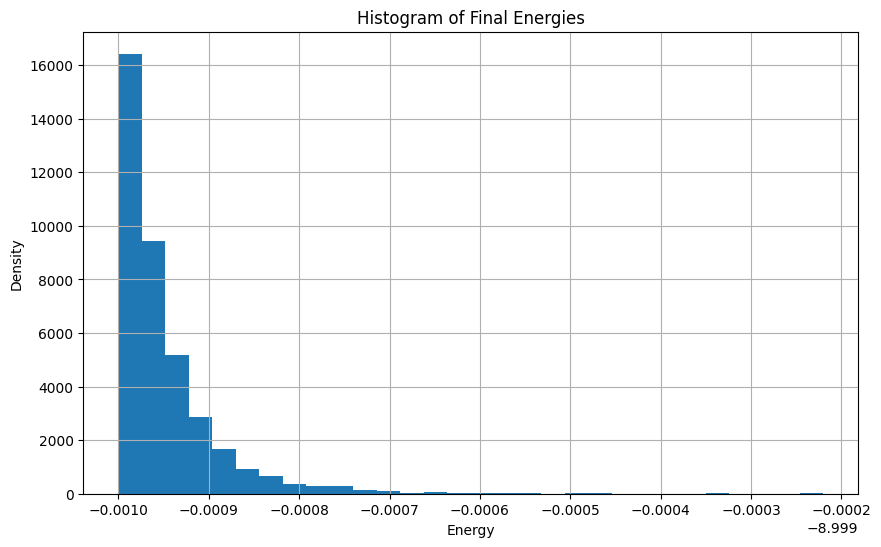

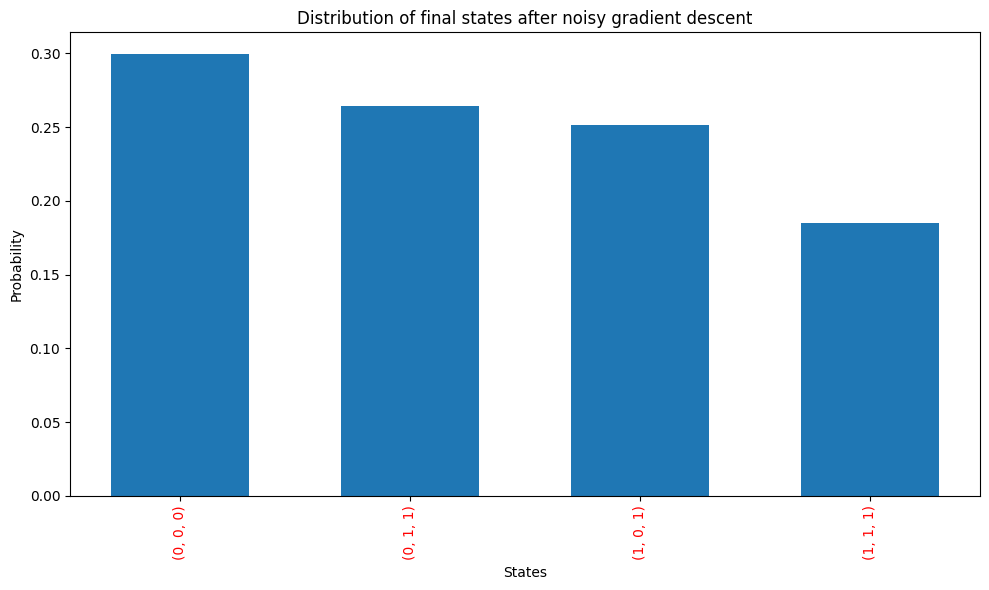

In [503]:
# Mimic ODE simulation

dt0 = 0.01
t_end = 20
dwt = 0.01

optimize_and_plot(
    j_mat=jnp.array(OR_J_MAT),
    Kc=1.0,
    Kl=1.0,
    n_harmonic=2,
    noise_std=dwt * dt0,
    noise_std_ratio=100,
    n_steps=int(t_end / dt0),
    n_trials=2**12,
    lr=dt0,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

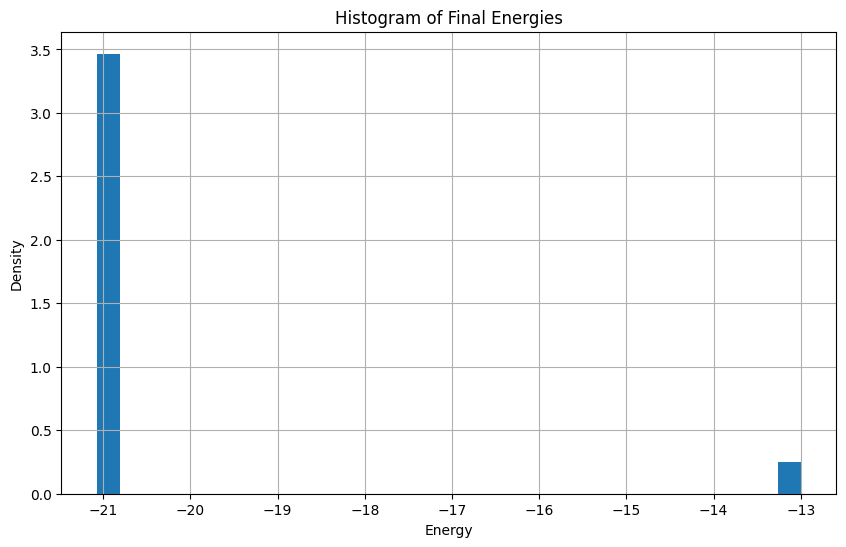

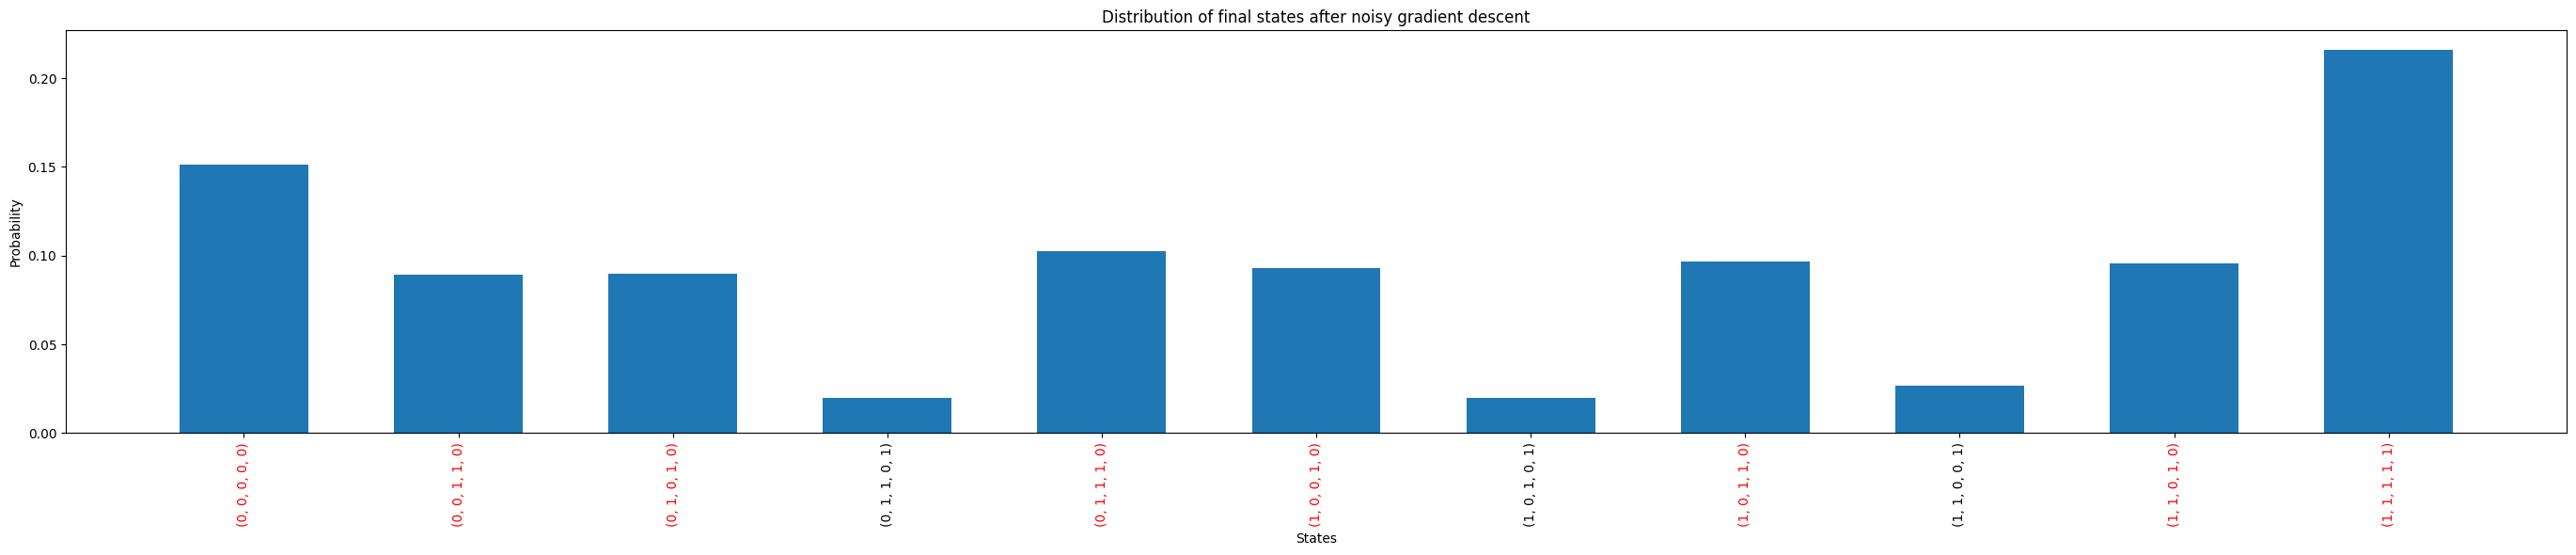

  0%|          | 0/10000 [00:00<?, ?it/s]

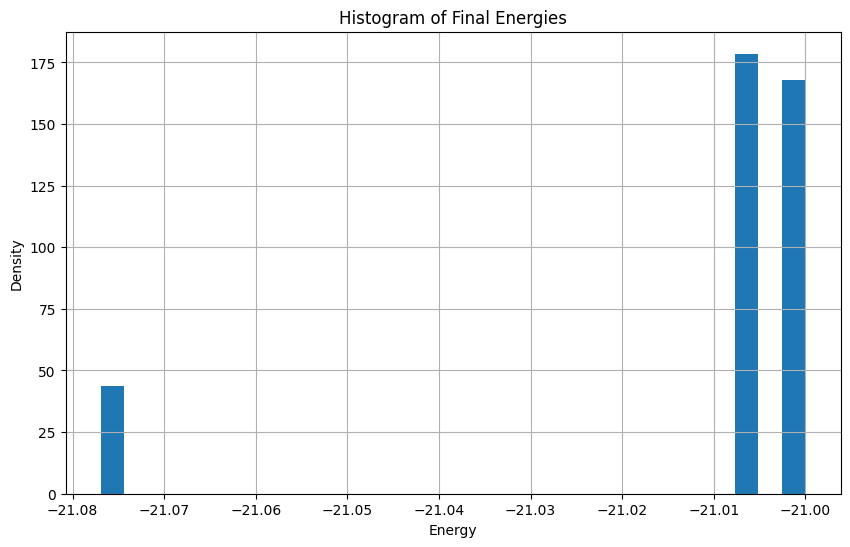

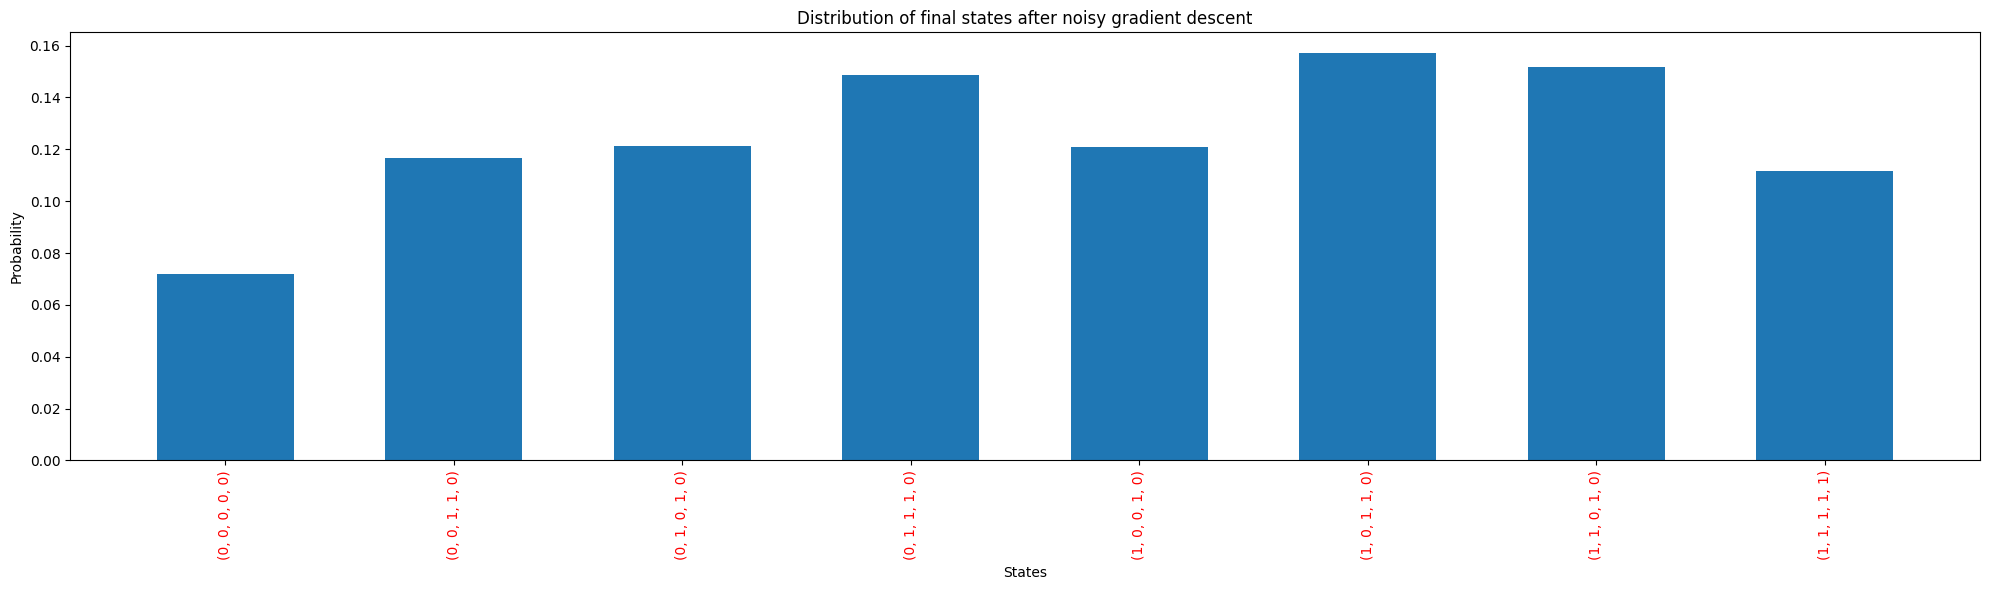

In [510]:
optimize_and_plot(
    j_mat=jnp.array(OR3_J_MAT),
    Kc=1.0,
    Kl=1.0,
    n_harmonic=2,
    noise_std=dwt * dt0,
    noise_std_ratio=100,
    n_steps=int(t_end / dt0),
    n_trials=2**12,
    lr=dt0,
)

# Extreme case: High noise ratio and long optimization

optimize_and_plot(
    j_mat=jnp.array(OR3_J_MAT),
    Kc=1.0,
    Kl=1.0,
    n_harmonic=2,
    noise_std=1e-5,
    noise_std_ratio=1e7,
    n_steps=10000,
    n_trials=2**12,
    lr=0.01,
)

### Deep AND gate

In [495]:
def build_deep_j_mat(n_level: int, base_j_mat: np.ndarray) -> np.ndarray:
    # Build a J matrix for a deep gate with n_level levels
    # 2 ** level - 1 oscillators in total, each level l has 2**l oscillators
    # for l in range(n_level). The ith oscillator is the input to the (i//2)th oscillator
    n_var_osc = 2**n_level - 1
    n_aux_osc = 2 ** (n_level - 1) - 1
    n_osc = n_var_osc + n_aux_osc
    j_mat = np.zeros((n_osc + 1, n_osc + 1))
    ref_idx = n_osc  # last oscillator is the reference

    out_idx = 0
    in1_idx = 1
    in2_idx = 2

    # Map the base_j_mat to the corresponding indices
    idx = np.ix_(
        [out_idx, in1_idx, in2_idx, ref_idx], [out_idx, in1_idx, in2_idx, ref_idx]
    )
    j_mat[idx] += base_j_mat

    for i in range(1, 2 ** (n_level - 1) - 1):
        out_idx = i
        in1_aux_idx = n_var_osc + 2 * i
        in2_aux_idx = n_var_osc + 2 * i + 1

        # Map the base_j_mat to the corresponding indices
        idx = np.ix_(
            [out_idx, in1_aux_idx, in2_aux_idx, ref_idx],
            [out_idx, in1_aux_idx, in2_aux_idx, ref_idx],
        )
        j_mat[idx] += base_j_mat

        # Connect output with the auxiliary oscillators with a negative coupling
        out_aux_idx = n_var_osc + i - 1
        j_mat[out_idx, out_aux_idx] -= 1
        j_mat[out_aux_idx, out_idx] -= 1

    return j_mat


def build_wide_j_mat(n_osc: int, base_j_mat: np.ndarray) -> np.ndarray:
    # Build a J matrix for a wide gate with n_level levels
    # oscillator 2i are output oscillator of oscillator 2i-1 and 2i-2
    assert n_osc >= 3 and n_osc % 2 == 1, "n_osc should be odd and >=3"
    j_mat = np.zeros((n_osc + 1, n_osc + 1))
    ref_idx = n_osc  # last oscillator is the reference

    for i in range(2, n_osc, 2):
        out_idx = i
        in1_idx = i - 1
        in2_idx = i - 2

        # Map the base_j_mat to the corresponding indices
        idx = np.ix_(
            [in1_idx, in2_idx, out_idx, ref_idx],
            [in1_idx, in2_idx, out_idx, ref_idx],
        )
        j_mat[idx] += base_j_mat

    return j_mat


# print(build_deep_j_mat(2, AND_J_MAT))
print(build_wide_j_mat(5, AND_J_MAT))

[[ 0.  1. -2.  0.  0. -1.]
 [ 1.  0. -2.  0.  0. -1.]
 [-2. -2.  0.  1. -2.  1.]
 [ 0.  0.  1.  0. -2. -1.]
 [ 0.  0. -2. -2.  0.  2.]
 [-1. -1.  1. -1.  2.  0.]]


  0%|          | 0/2000 [00:00<?, ?it/s]

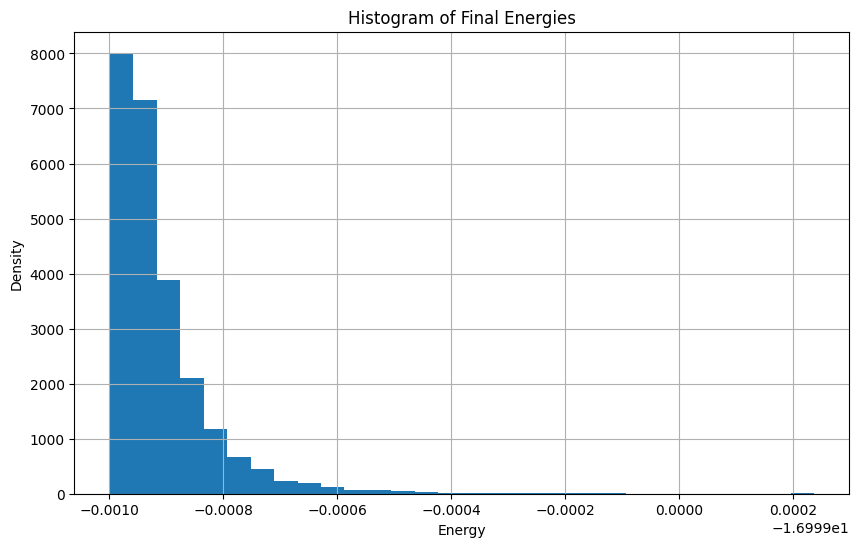

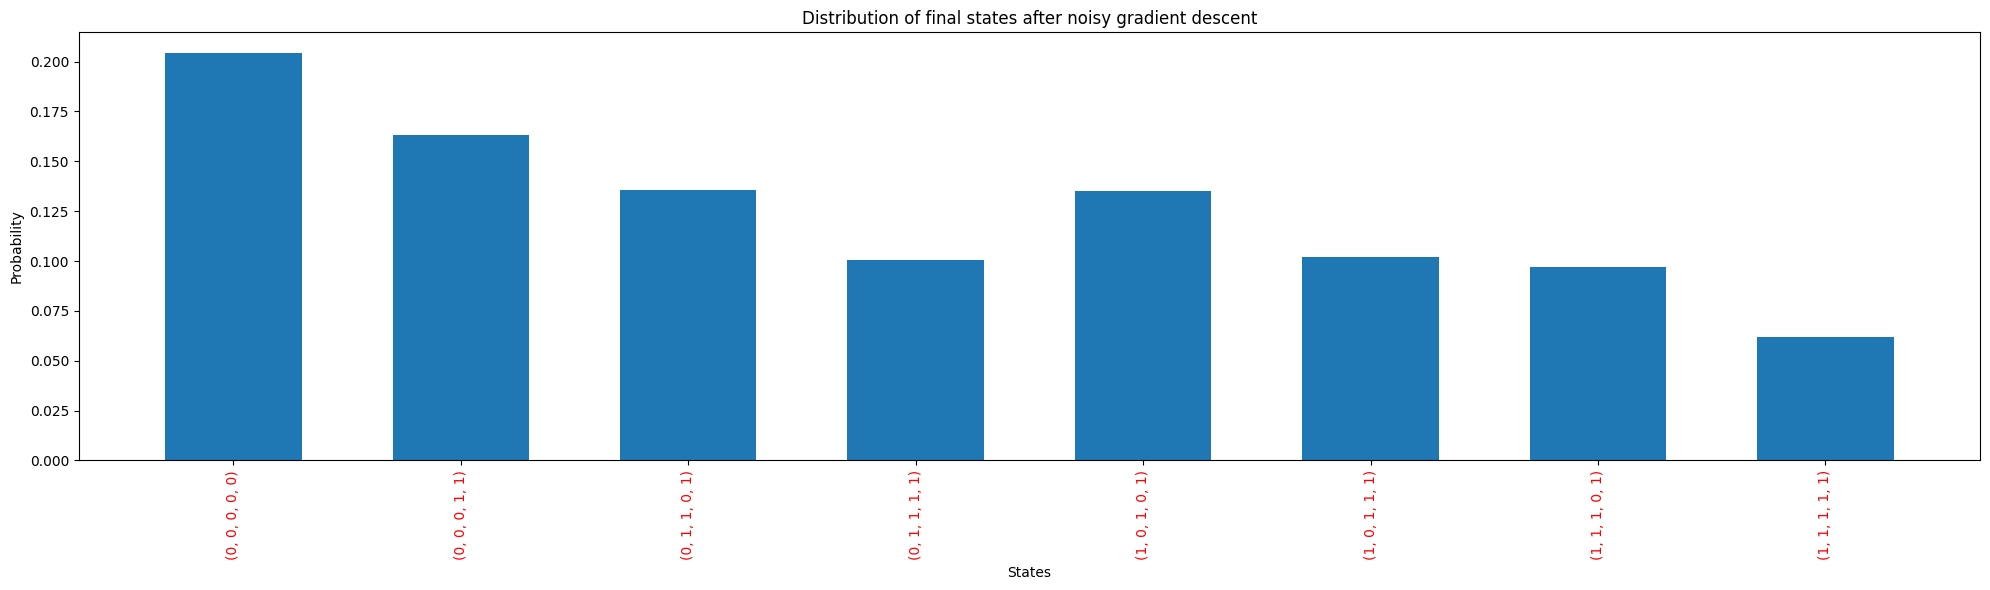

  0%|          | 0/10000 [00:00<?, ?it/s]

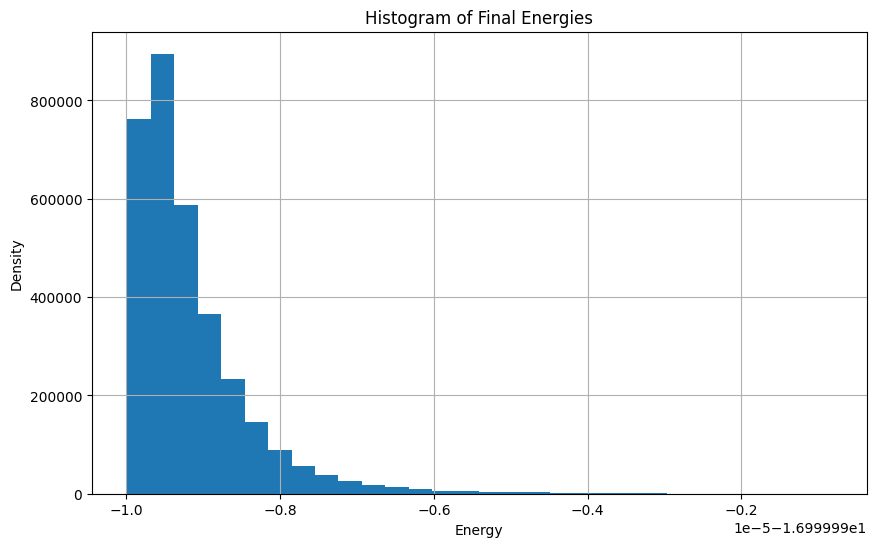

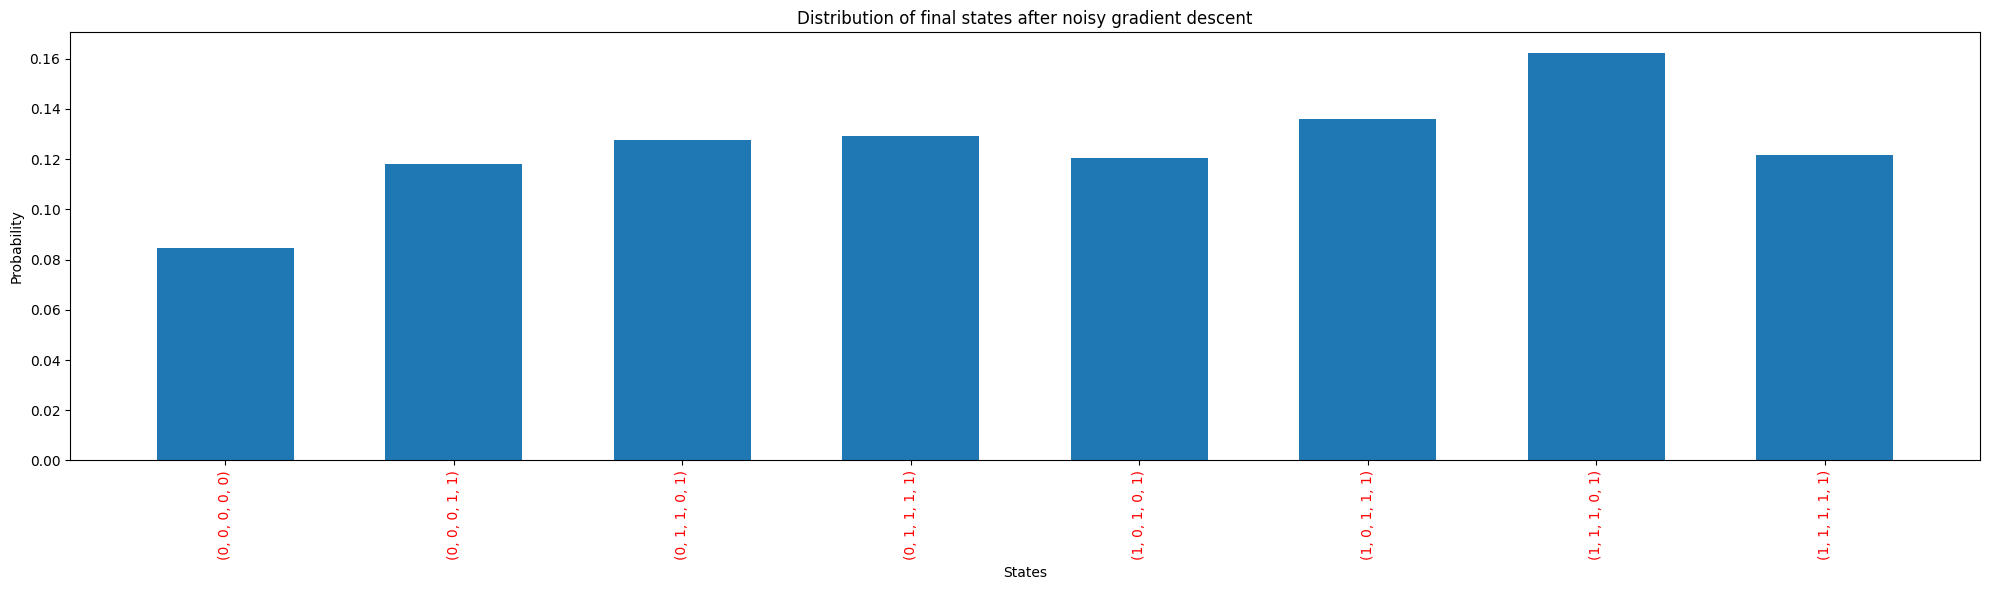

In [ ]:
for n_level in [5]:
    deep_and_j = build_wide_j_mat(n_level, OR_J_MAT)
    optimize_and_plot(
        j_mat=jnp.array(deep_and_j),
        Kc=1.0,
        Kl=1.0,
        n_harmonic=2,
        noise_std=dwt * dt0,
        noise_std_ratio=100,
        n_steps=int(t_end / dt0),
        n_trials=2 ** (9 + n_level),
        lr=dt0,
    )

    optimize_and_plot(
        j_mat=jnp.array(deep_and_j),
        Kc=1.0,
        Kl=1.0,
        n_harmonic=2,
        noise_std=1e-5,
        noise_std_ratio=1e7,
        n_steps=10000,
        n_trials=2 ** (9 + n_level),
        lr=0.01,
    )

In [374]:
# Plot the 4D energy function for 2-AND gate
%matplotlib qt

def plot_energy_landscape_3d(j_mat: jax.Array, Kc: float, Kl: float, n_harmonic: int, beta: float):
    energy = get_energy_fn(j_mat, Kc, Kl, n_harmonic)
    # Enumerate all states
    n_osc = j_mat.shape[0] - 1
    states = [tuple(i) for i in product(range(n_harmonic), repeat=n_osc)]


    max_prob_ratio = jnp.exp(-beta * energy(jnp.array([0, 1, 0])))
    # max_prob_ratio = energy(jnp.array([0, 1, 0]), J=jnp.array(AND_J_MAT))

    for state in states:
        phase_coords, prob_ratio = [], []

        phase_vals = [s * (2 * np.pi / n_harmonic) for s in state]
        ranges = [
            (phase_val - np.pi / n_harmonic, phase_val + np.pi / n_harmonic)
            for phase_val in phase_vals
        ]

        # Sample points within the ranges for visualization
        sample_points = [np.linspace(r[0], r[1], 10) for r in ranges]
        mesh = np.meshgrid(*sample_points)
        points = np.vstack([m.flatten() for m in mesh]).T
        HAS_POINTS = False
        cutoff = 0.5
        for point in points:
            energy_val = energy(jnp.array(point))
            norm_prob_ratio = jnp.exp(-beta * energy_val) / max_prob_ratio
            # norm_prob_ratio = energy_val / max_prob_ratio

            # Filter to plot only points within greater than cutoff probability ratio
            if norm_prob_ratio < cutoff:
                continue
            HAS_POINTS = True
            phase_coords.append(point)
            prob_ratio.append(norm_prob_ratio)

        # Scatter plot of the probabilities in 3D phase space
        phase_coords = np.array(phase_coords)
        if not HAS_POINTS:
            print(f"No high-probability points for state {state}, skipping plot.")
            continue

        prob = jnp.array(prob_ratio)
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        # Set color bar max/min to max_prob_ratio/0
        scat = ax.scatter(
            phase_coords[:, 0],
            phase_coords[:, 1],
            phase_coords[:, 2],
            c=prob,
            cmap="coolwarm",
            alpha=0.2,
            vmin=0,
            vmax=1,
        )
        fig.colorbar(scat, ax=ax, label="Normalized exp(-βE)")

        ax.set_xlabel("Phase 0")
        ax.set_ylabel("Phase 1")
        ax.set_zlabel("Phase 2")

        # Set x,y,z ticks to multiples of pi
        # x from ranges[0], y from ranges[1], z from ranges[2]
        x_ticks = np.arange(ranges[0][0], ranges[0][1] + 0.1, np.pi / 2)
        y_ticks = np.arange(ranges[1][0], ranges[1][1] + 0.1, np.pi / 2)
        z_ticks = np.arange(ranges[2][0], ranges[2][1] + 0.1, np.pi / 2)
        ax.set_xticks(x_ticks)
        ax.set_yticks(y_ticks)
        ax.set_zticks(z_ticks)
        ax.set_xticklabels([f"{t/np.pi:.1f}π" for t in x_ticks])
        ax.set_yticklabels([f"{t/np.pi:.1f}π" for t in y_ticks])
        ax.set_zticklabels([f"{t/np.pi:.1f}π" for t in z_ticks])

        plt.title("State " + str(state))
        plt.show()

plot_energy_landscape_3d(
    j_mat=jnp.array(AND_J_MAT),
    Kc=1.0,
    Kl=1.0,
    n_harmonic=2,
    beta=1.0,
)

No high-probability points for state (0, 0, 1), skipping plot.
No high-probability points for state (0, 1, 1), skipping plot.
No high-probability points for state (1, 0, 1), skipping plot.
No high-probability points for state (1, 1, 0), skipping plot.


In [ ]:
# Optimize the J matrix for balanced state distribution

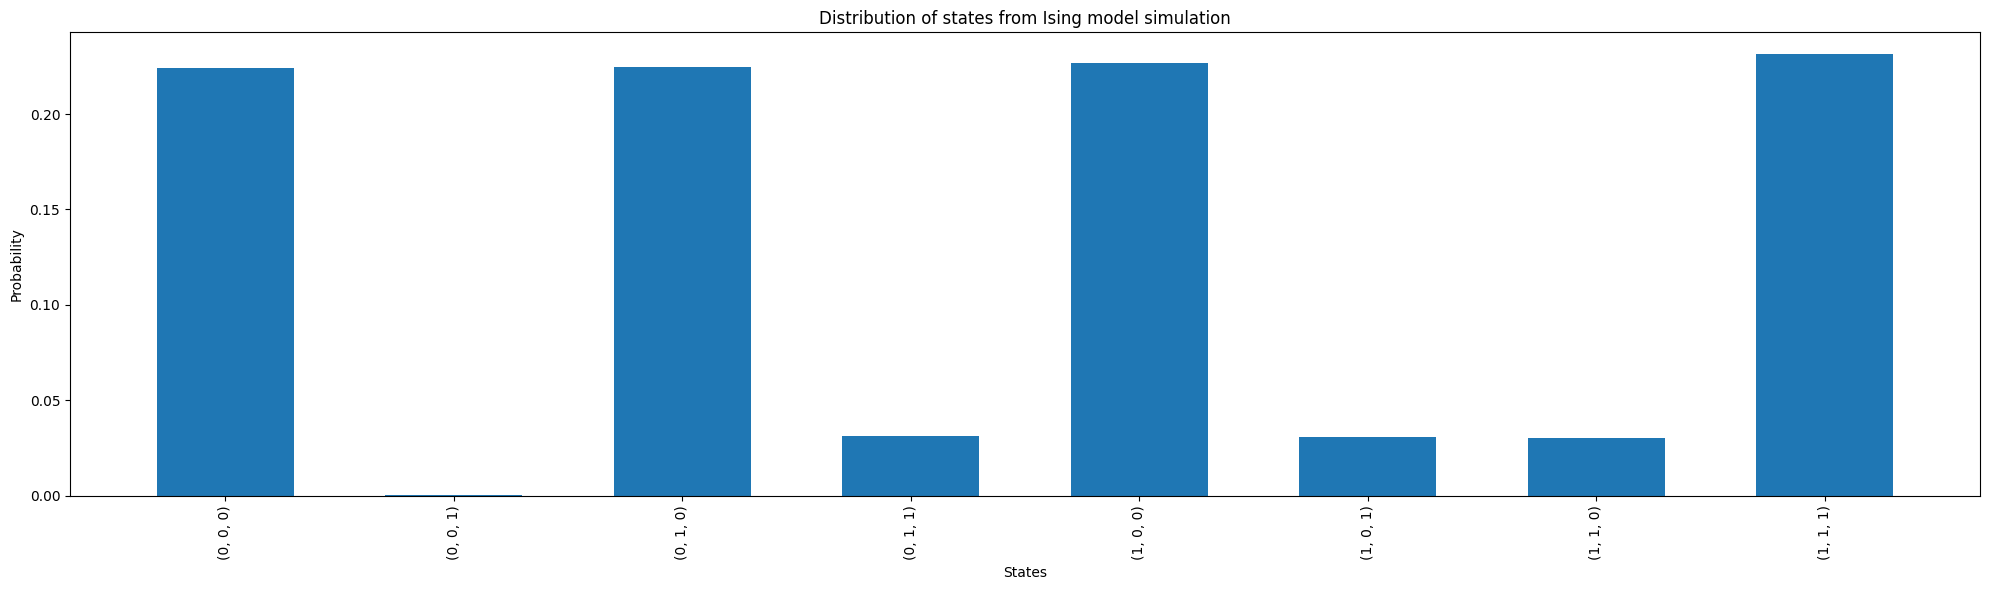

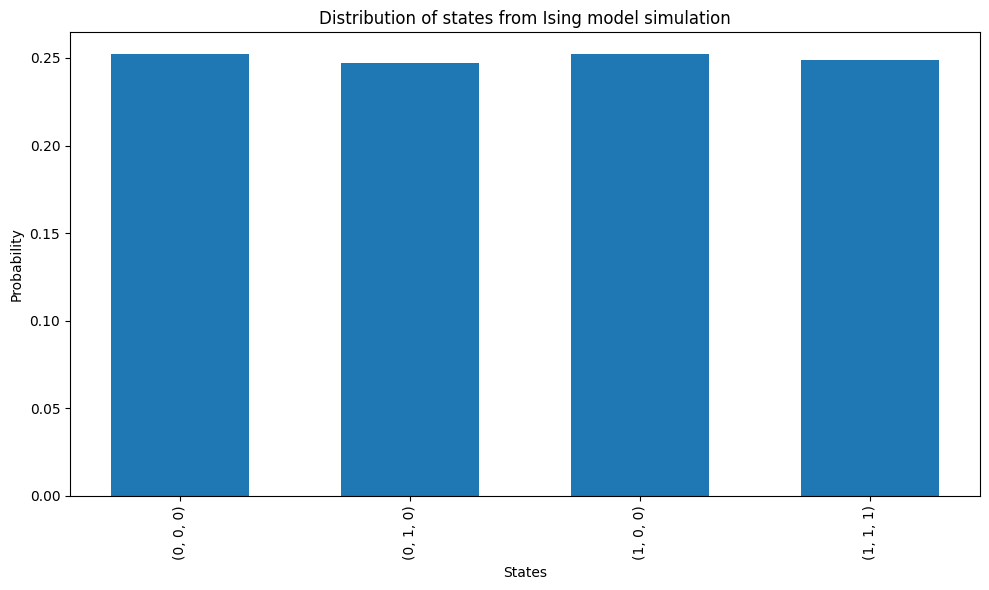

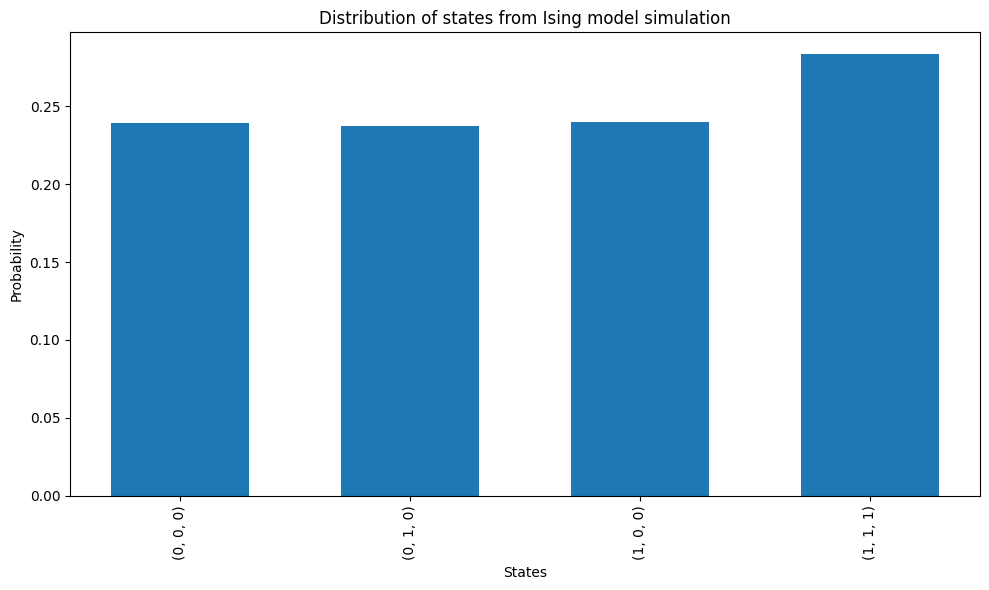

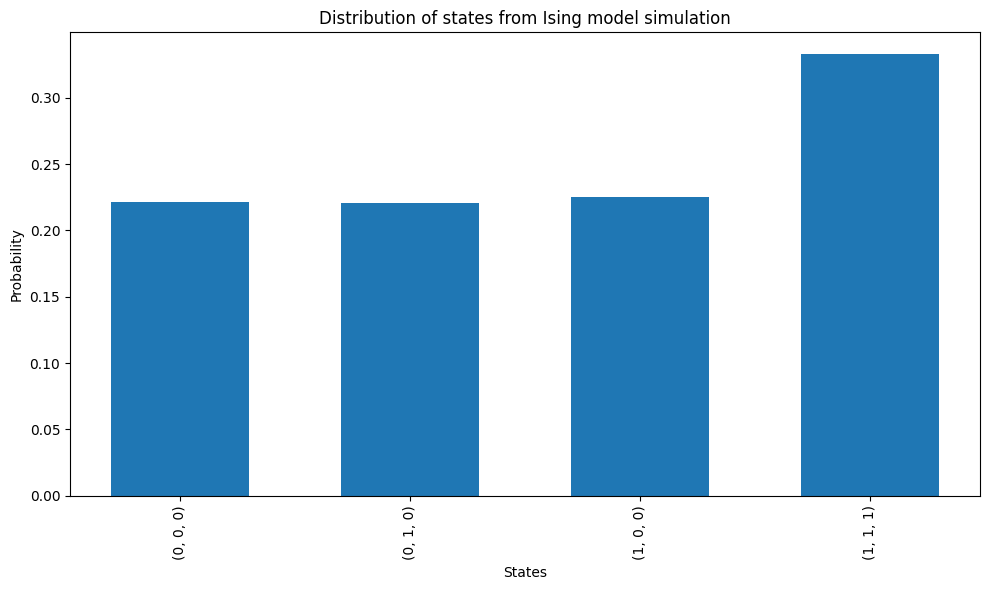

In [579]:
# Simulate Ising model with the same J matrices and examine the state distribution
import dimod
from dwave.samplers import SimulatedAnnealingSampler


def sim_and_plot_ising(j: np.ndarray, beta_end: float):
    j_mat = j[:-1, :-1]
    h = j[-1, :-1] * 2
    sampler = SimulatedAnnealingSampler()
    # sampler = RandomSampler()
    sampleset = sampler.sample_ising(
        h,
        j_mat,
        num_reads=2**15,
        num_sweeps=2000,
        beta_range=(beta_end / 100, beta_end),
        randomize_order=True,
    )

    state_counts = {}
    for sample in sampleset.samples():
        state = tuple((s.item() + 1) // 2 for s in sample.values())
        state_counts[state] = state_counts.get(state, 0) + 1
    states = list(sorted(state_counts.keys()))

    counts = np.array([state_counts[state] for state in states])
    probs = counts / np.sum(counts)
    # Plot the histogram
    plt.figure(figsize=(10 / 4 * len(states), 6))
    plt.bar(
        np.arange(len(states)),
        probs,
        width=0.6,
    )
    plt.xticks(np.arange(len(states)), states, rotation=90)
    plt.xlabel("States")
    plt.ylabel("Probability")
    plt.title("Distribution of states from Ising model simulation")
    plt.tight_layout()
    plt.show()

    return


for beta_end in [0.25, 4, 64, 256]:
    # for j in [wide_and_j, AND_J_MAT, OR_J_MAT, XOR_J_MAT, OR3_J_MAT]:
    for j in [AND_J_MAT]:
        sim_and_plot_ising(j=j, beta_end=beta_end)

n_steps=100000, noise_std=0.00010000000000000002, noise_std_ratio=224.99999999999997


  0%|          | 0/100000 [00:00<?, ?it/s]

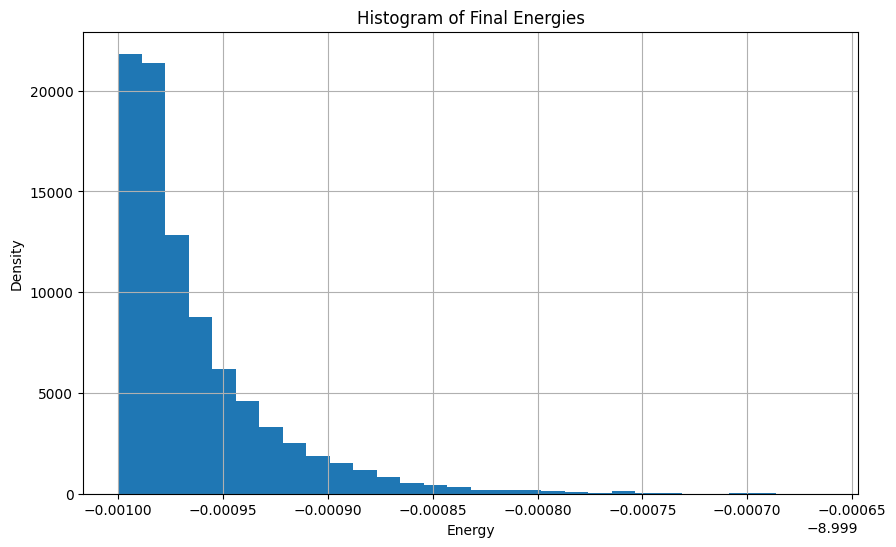

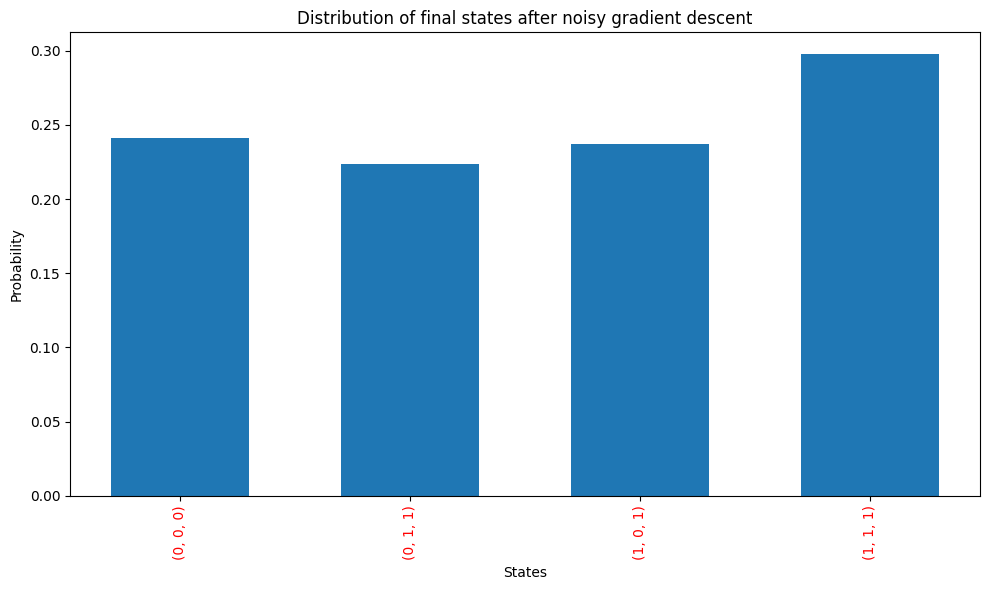

In [639]:
# Extreme case: High noise ratio and long optimization

noise_base = 1e-4
noise_std_ratio_base = 2.25e2
n_steps_base = 100000
# n_steps_base = 10000

init_noise = noise_base * noise_std_ratio_base

# for n_steps in [100, 1000, 5000, 10000]:
for n_steps in [100000]:
    noise_std = init_noise * jnp.exp(
        -jnp.log(noise_std_ratio_base) * n_steps / n_steps_base
    )
    noise_std_ratio = init_noise / noise_std
    print(
        f"n_steps={n_steps}, noise_std={noise_std}, noise_std_ratio={noise_std_ratio}"
    )

    optimize_and_plot(
        j_mat=jnp.array(OR_J_MAT),
        Kc=1.0,
        Kl=1.0,
        n_harmonic=2,
        noise_std=noise_std,
        noise_std_ratio=noise_std_ratio,
        n_steps=n_steps,
        n_trials=2**13,
        lr=0.01,
    )

State (0, 0, 0):
Integrate from ranges [('-1.57', '1.57'), ('-1.57', '1.57'), ('-1.57', '1.57')]:
	24441766.481248647 ± 0.5830038818259924
State (0, 0, 1):
Integrate from ranges [('-1.57', '1.57'), ('-1.57', '1.57'), ('1.57', '4.71')]:
	65186.12407548854 ± 0.0006314789176666835
State (0, 1, 0):
Integrate from ranges [('-1.57', '1.57'), ('1.57', '4.71'), ('-1.57', '1.57')]:
	16765.66102324784 ± 0.00029931559922767494
State (0, 1, 1):
Integrate from ranges [('-1.57', '1.57'), ('1.57', '4.71'), ('1.57', '4.71')]:
	42600031.61326605 ± 0.5237741304658847
State (1, 0, 0):
Integrate from ranges [('1.57', '4.71'), ('-1.57', '1.57'), ('-1.57', '1.57')]:
	16765.661023248445 ± 0.00013526832909935933
State (1, 0, 1):
Integrate from ranges [('1.57', '4.71'), ('-1.57', '1.57'), ('1.57', '4.71')]:
	42600031.61327508 ± 0.5853705661712603
State (1, 1, 0):
Integrate from ranges [('1.57', '4.71'), ('1.57', '4.71'), ('-1.57', '1.57')]:
	5.412086638305498 ± 2.3395930523109166e-07
State (1, 1, 1):
Integrate

/var/folders/zv/1cq_05k97dl9b9_kf_drhmdr0000gp/T/ipykernel_26315/3936308631.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


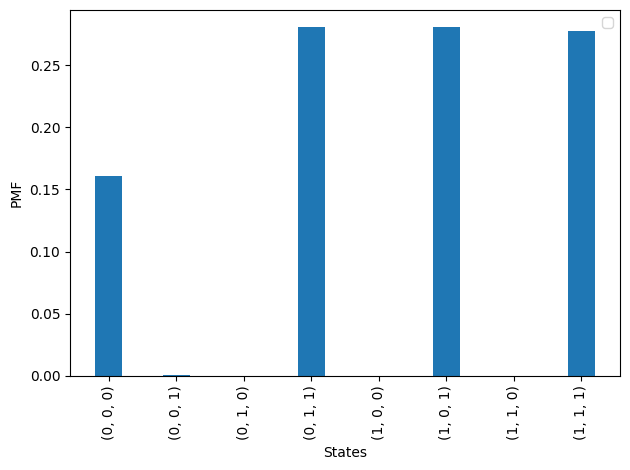

In [590]:
num_int_exp_energy(j_mat=OR_J_MAT, beta=2.0)